# Combined Run 2 + Run 3 — Signal vs Background (1L2Tau)

Chain (concatenate) **all** backgrounds and **both** signals (ggF + VBF) from
**Run 2 and Run 3** into a single training sample, then train the same
XGBoost signal-vs-background BDT used in `First_Training.ipynb` on the
combined data.

Goal: check whether the feature-importance ranking learned on the combined
Run2+Run3 sample differs from the rankings learned separately on Run 2 alone
and Run 3 alone (see `First_Training.ipynb`).

Kept identical to `First_Training.ipynb`:
- same tree (`AnalysisMiniTree`), same preselection (`n_b_jet == 0 & n_jet >= 2`)
- same leakage-free feature-selection policy (`is_feature` blocklist)
- same weight handling (`w_phys = weight * weights`, |w| for training, signal
  rescaled to balance background, mean weight normalized to 1)
- same diagnostics: total-gain / gain feature importance, correlation
  heatmaps (signal vs background), correlation-based pruning to a
  decorrelated top-20 set, and a retrained "after cut" model

New relative to `First_Training.ipynb`:
- the feature list is restricted to branches common to **all 20 files**
  (10 processes × 2 runs), not just the 10 files of a single run
- an extra `run` column (2 or 3) is kept as bookkeeping (never used as a
  training feature) so we can check the run mix in train/val
- a final comparison cell checks how the Run-2-only Optuna feature set
  (persisted in `optuna_features_run2.json`) ranks inside the combined model


In [1]:
import uproot, pandas as pd, numpy as np
from pathlib import Path

# ---- Configuration --------------------------------------------------------
BASE_DIR_R2 = Path("PPSSP_2026/1l2tau/run2")   # 1 lepton + 2 taus, Run 2
BASE_DIR_R3 = Path("PPSSP_2026/1l2tau/run3")   # 1 lepton + 2 taus, Run 3
TREE_NAME   = "AnalysisMiniTree"

# Preselection cuts for the 1L2Tau channel (see README) - same as First_Training.ipynb
PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# --- Feature selection policy (identical to First_Training.ipynb) ---------
# Load generously and let XGBoost prune via importance, BUT never let these
# branches enter as features (they poison the training / leak the label):
#   - weights & scale/fake factors  -> differ systematically signal vs bkg
#   - dsid / eventNumber            -> sample/event identifiers (label in disguise)
#   - *truth* / isTrue* / *fake*    -> generator info, absent in real data
#   - anti-tau bookkeeping          -> fake-region definition, process-dependent
#   - preselection constants        -> n_b_jet==0 always; pass1l2tau==1 always

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti", "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT  = {"n_b_jet", "pass1l2tau", "hhml_subchannelflavor", "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans", "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig"}
BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}

def is_feature(branch: str) -> bool:
    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)

WEIGHT_PARTS = ["weight", "weights"]   # raw branches; w_phys = their product

files = {
    # process    : (filename, label)   1 = signal, 0 = background
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",         0),
}

RUNS = [(2, BASE_DIR_R2), (3, BASE_DIR_R3)]

# Build the feature list from branches COMMON to ALL 20 files (10 processes x
# 2 runs), not just one run's 10 files - a feature dropped here would
# otherwise silently vanish once the two runs are concatenated.

common = None
for run_label, base_dir in RUNS:
    for proc, (fname, _) in files.items():
        keys = set(uproot.open({str(base_dir / fname): TREE_NAME}).keys())
        common = keys if common is None else common & keys
features = sorted(b for b in common if is_feature(b))

print(f"{len(features)} candidate features (common to all {len(files)} processes x {len(RUNS)} runs = {len(files) * len(RUNS)} files, leakage-free)\n")


87 candidate features (common to all 10 processes x 2 runs = 20 files, leakage-free)



In [2]:
# ---- Extraction loop: chain Run 2 + Run 3, all processes -------------------
# Label: 1 = signal (ggF+VBF), 0 = background - SAME convention as
# First_Training.ipynb. The `run` column is bookkeeping only (2 or 3), never
# added to `features`, so it can't leak into the training.

dfs = []

for run_label, base_dir in RUNS:
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(features + WEIGHT_PARTS, cut=PRESELECTION, library="pd")

        """
        'weight'       = sigma*L/sum_w_gen, per DSID+campaign (raw branch, untouched)
        'weight_final' = generator event weight, Sherpa NLO -> negatives (raw branch, untouched)
        'w_phys'       = physical event weight -> use for training & yields
        """

        df["w_phys"]  = df["weight"] * df["weights"]
        df["label"]   = label     # 1 = signal, 0 = background
        df["process"] = proc      # keep track of the originating process
        df["run"]     = run_label # 2 or 3 - bookkeeping only, NOT a feature
        dfs.append(df)
        print(f"Run {run_label} {proc:12s}: {len(df):>8d} events after preselection")

data = pd.concat(dfs, ignore_index=True)

print(f"\nTotal chained (Run2+Run3) events: {len(data)}")
print(f"  Run 2: {(data.run==2).sum()} | Run 3: {(data.run==3).sum()}")
print(f"  signal: {(data.label==1).sum()} | background: {(data.label==0).sum()}")


Run 2 signal_ggF  :    67075 events after preselection
Run 2 signal_VBF  :    21639 events after preselection
Run 2 Diboson     :   312600 events after preselection
Run 2 Zjets       :   141863 events after preselection
Run 2 Wjets       :    31272 events after preselection
Run 2 ttbar       :     7335 events after preselection
Run 2 tops        :    62238 events after preselection
Run 2 SingleH     :    11124 events after preselection
Run 2 Vgamma      :    21510 events after preselection
Run 2 VVV         :    14028 events after preselection
Run 3 signal_ggF  :   191580 events after preselection
Run 3 signal_VBF  :    13470 events after preselection
Run 3 Diboson     :   628676 events after preselection
Run 3 Zjets       :   157073 events after preselection
Run 3 Wjets       :    39061 events after preselection
Run 3 ttbar       :    40832 events after preselection
Run 3 tops        :   161226 events after preselection
Run 3 SingleH     :    38425 events after preselection
Run 3 Vgam

In [3]:
# ---- Post-concat cleaning --------------------------------------------------
# 1) Constant / empty features (zero variance, all-NaN or all-sentinel) -> drop
#    (checked on the COMBINED data, so a feature constant in only one run is
#    also caught here)

nun = data[features].nunique()
const = nun[nun <= 1].index.tolist()
features = [f for f in features if f not in const]
data = data.drop(columns=const)
print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

# 2) Sentinel values (e.g. -999) -> NaN; XGBoost routes NaNs natively.
#    Safe threshold here: all legit features are > -100 (eta, phi, pdg, charge).

for f in features:
    m = data[f] < -100
    if m.any():
        print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
        data[f] = data[f].mask(m)

print(f"\n{len(features)} final features")
print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | background = {(data.label==0).sum()}")
print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | background = {data.loc[data.label==0,'w_phys'].sum():.2f}")

# Per-run yield breakdown - confirms both runs contribute comparable statistics
# to the chained sample (no run silently dominating the training).
for run_label in (2, 3):
    sub = data[data.run == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")

data.head()


Dropped 19 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_decayMode', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_decayMode', 'tau2_passOR']

68 final features
Total: 2015576 events | signal = 293764 | background = 1721812
Yield (w_phys): signal = 3.91 | background = 30834.21
Run 2: signal yield = 1.82 | background yield = 11467.29 | n_events = 690684
Run 3: signal yield = 2.08 | background yield = 19366.92 | n_events = 1324892


,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_eta,tau2_nprong,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,486197.28125,437935.43750,350626.937500,42837.089844,91098.921875,44471.410156,77389.632812,91956.718750,12270.166016,2.849011,...,0.794897,1,-3.045134,22102.740234,0.00125,-0.028450,-0.000036,1,signal_ggF,2
1,233307.37500,192779.18750,92852.828125,31019.406250,71547.601562,68906.953125,35689.703125,32890.671875,20957.582031,2.693458,...,2.437175,1,1.528327,30261.955078,0.00125,0.054811,0.000069,1,signal_ggF,2
2,399998.12500,345424.46875,107697.429688,164906.187500,219479.843750,72820.843750,127177.953125,97451.046875,33988.949219,0.399682,...,0.301610,1,0.593764,33664.312500,0.00125,0.029853,0.000037,1,signal_ggF,2
3,344867.65625,249412.12500,165593.328125,21953.849609,117409.382812,61864.949219,36656.707031,111334.617188,18972.347656,2.708711,...,1.256151,1,0.694036,21605.847656,0.00125,0.030944,0.000039,1,signal_ggF,2
4,326392.68750,270753.15625,128916.000000,71331.773438,126971.281250,70505.390625,129401.234375,129401.234375,55308.082031,2.955379,...,-0.066556,1,-1.724129,31729.716797,0.00125,0.032416,0.000041,1,signal_ggF,2


In [ ]:
from sklearn.model_selection import train_test_split

# 80 / 20 train-validation split. Stratify on label AND run jointly (not just
# label, unlike the single-run notebooks) so the chained train/val split keeps
# the same Run2/Run3 mix in both partitions.

strata = data["label"].astype(str) + "_" + data["run"].astype(str)

train_df, val_df = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=strata,
)

X_train = train_df[features]
y_train = train_df["label"]
w_train = train_df["w_phys"]

X_val = val_df[features]
y_val = val_df["label"]
w_val = val_df["w_phys"]

print(f"Train: {len(train_df)} events | signal = {(y_train==1).sum()} | background = {(y_train==0).sum()}")
print(f"Val:   {len(val_df)} events | signal = {(y_val==1).sum()} | background = {(y_val==0).sum()}")
print(f"Train run mix: Run2 = {(train_df.run==2).sum()} | Run3 = {(train_df.run==3).sum()}")
print(f"Val run mix:   Run2 = {(val_df.run==2).sum()} | Run3 = {(val_df.run==3).sum()}")


Train: 1612460 events | signal = 235011 | background = 1377449
Val:   403116 events | signal = 58753 | background = 344363
Train run mix: Run2 = 552547 | Run3 = 1059913
Val run mix:   Run2 = 138137 | Run3 = 264979


## XGBoost (Combined Run 2 + Run 3)


In [5]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# --- Training weights -------------------------------------------------------
# 1) w_phys has negatives (Sherpa NLO). Negative sample_weights corrupt the
#    boosting gradients, so for TRAINING we use |w_phys| (yields keep the sign).
# 2) Class balance: rescale signal so both classes have equal total weight
#    (same convention as First_Training.ipynb, now computed on the chained
#    Run2+Run3 training partition).
# 3) Normalize mean weight to 1 so min_child_weight etc. behave like event counts.

w_fit = np.abs(w_train.to_numpy())

sum_sig, sum_bkg = w_fit[y_train == 1].sum(), w_fit[y_train == 0].sum()
w_fit[y_train == 1] *= sum_bkg / sum_sig
w_fit *= len(w_fit) / w_fit.sum()

w_val_fit = np.abs(w_val.to_numpy())   # for the weighted validation AUC

print(f"signal weight scale factor: {sum_bkg/sum_sig:.1f}")

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.10,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
)

model.fit(
    X_train, y_train,
    sample_weight=w_fit,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[w_val_fit],
    verbose=50,
)

print(f"\nBest iteration: {model.best_iteration}")
auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1], sample_weight=np.abs(w_train))
auc_val   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1],   sample_weight=w_val_fit)
print(f"Weighted AUC: train = {auc_train:.4f} | validation = {auc_val:.4f}")


signal weight scale factor: 10871.5
[0]	validation_0-auc:0.90943
[50]	validation_0-auc:0.93651
[100]	validation_0-auc:0.94223
[150]	validation_0-auc:0.94454
[200]	validation_0-auc:0.94623
[250]	validation_0-auc:0.94670
[300]	validation_0-auc:0.94714
[350]	validation_0-auc:0.94780
[400]	validation_0-auc:0.94786
[416]	validation_0-auc:0.94790

Best iteration: 386
Weighted AUC: train = 0.9697 | validation = 0.9479


Top 30 features by total gain (Combined Run2+Run3):
               total_gain  gain_frac  weight
HT_tau       3.142422e+06   0.473743   528.0
dR_t1t2      3.520062e+05   0.053067   820.0
SumPt_t1t2   2.207768e+05   0.033284   661.0
m_t1t2       2.023292e+05   0.030503   834.0
HT           1.943568e+05   0.029301   401.0
dR_l1j1      1.777731e+05   0.026801   507.0
tau1_pt      1.735210e+05   0.026160   436.0
met_sumet    1.573870e+05   0.023727   556.0
m_l1j        1.376461e+05   0.020751   521.0
tau2_pt      1.350074e+05   0.020353   587.0
met_met      9.813385e+04   0.014794   611.0
m_ttl        8.406811e+04   0.012674   427.0
dR_t1t2_l1   7.229959e+04   0.010900   518.0
m_l1t        6.588190e+04   0.009932   467.0
m_l1j1       5.951154e+04   0.008972   424.0
HT_lepMET    5.503885e+04   0.008298   462.0
dR_l1t       5.281612e+04   0.007962   419.0
tau2_charge  5.281393e+04   0.007962    83.0
dR_l1j2      5.165620e+04   0.007788   418.0
m_l1t1       5.112507e+04   0.007707   461.0
l1_

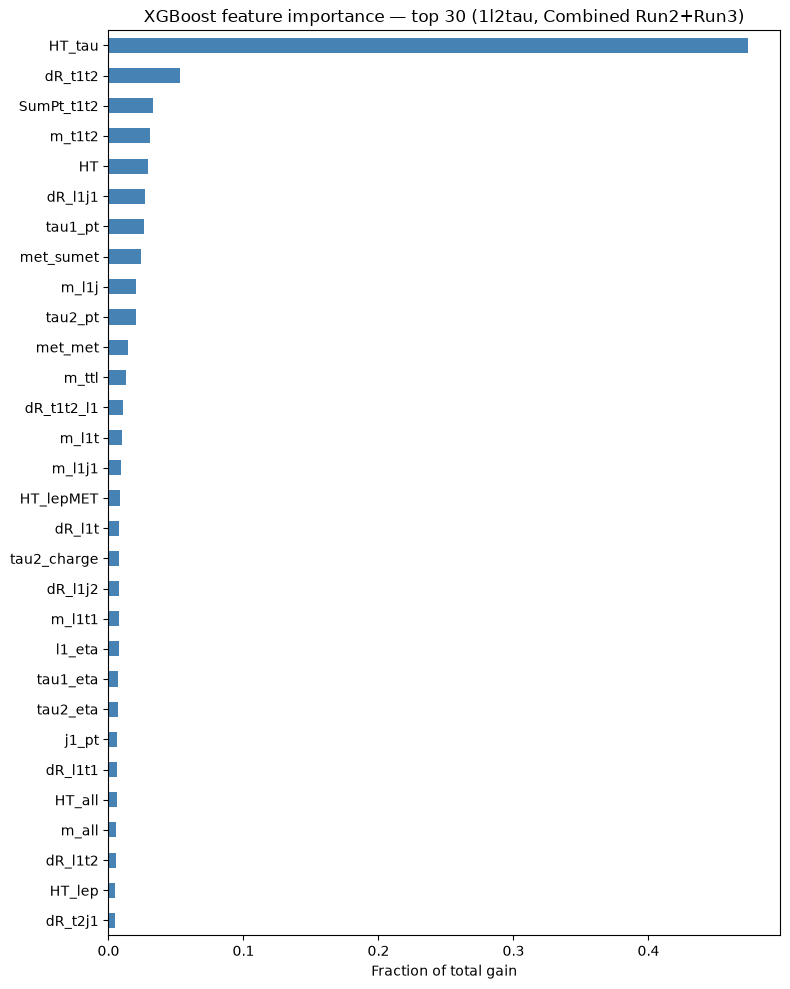

In [6]:
import matplotlib.pyplot as plt

# --- Feature importance ------------------------------------------------------
# total_gain = total loss reduction contributed by a feature (best for ranking).
booster = model.get_booster()

imp = pd.DataFrame({
    t: booster.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(features).fillna(0.0)

imp = imp.sort_values("total_gain", ascending=False)
imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()

print("Top 30 features by total gain (Combined Run2+Run3):")
print(imp[["total_gain", "gain_frac", "weight"]].head(30).to_string())
print(f"\nFeatures never used in a split: {(imp['total_gain'] == 0).sum()} / {len(features)}")

TOP_N = 30

fig, ax = plt.subplots(figsize=(8, 10))
imp["gain_frac"].head(TOP_N)[::-1].plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance — top {TOP_N} (1l2tau, Combined Run2+Run3)")
plt.tight_layout()
plt.show()


Top 30 features by average gain (Combined Run2+Run3):
                    gain  gain_share  weight
HT_tau       5951.557129    0.394600   528.0
tau2_charge   636.312439    0.042189    83.0
HT            484.680328    0.032135   401.0
dR_t1t2       429.275909    0.028462   820.0
tau1_pt       397.983978    0.026387   436.0
dR_l1j1       350.637299    0.023248   507.0
SumPt_t1t2    334.004303    0.022145   661.0
pass_LTT      309.890137    0.020546    38.0
met_sumet     283.070221    0.018768   556.0
m_l1j         264.195984    0.017517   521.0
tau1_charge   261.842316    0.017361    63.0
m_t1t2        242.600983    0.016085   834.0
l1_charge     233.775909    0.015500    61.0
tau2_pt       229.995636    0.015249   587.0
m_ttl         196.880814    0.013054   427.0
tau2_nprong   194.295425    0.012882   101.0
pass_DTT      183.617447    0.012174    24.0
met_met       160.611862    0.010649   611.0
m_l1t         141.074722    0.009354   467.0
m_l1j1        140.357407    0.009306   424.0
d

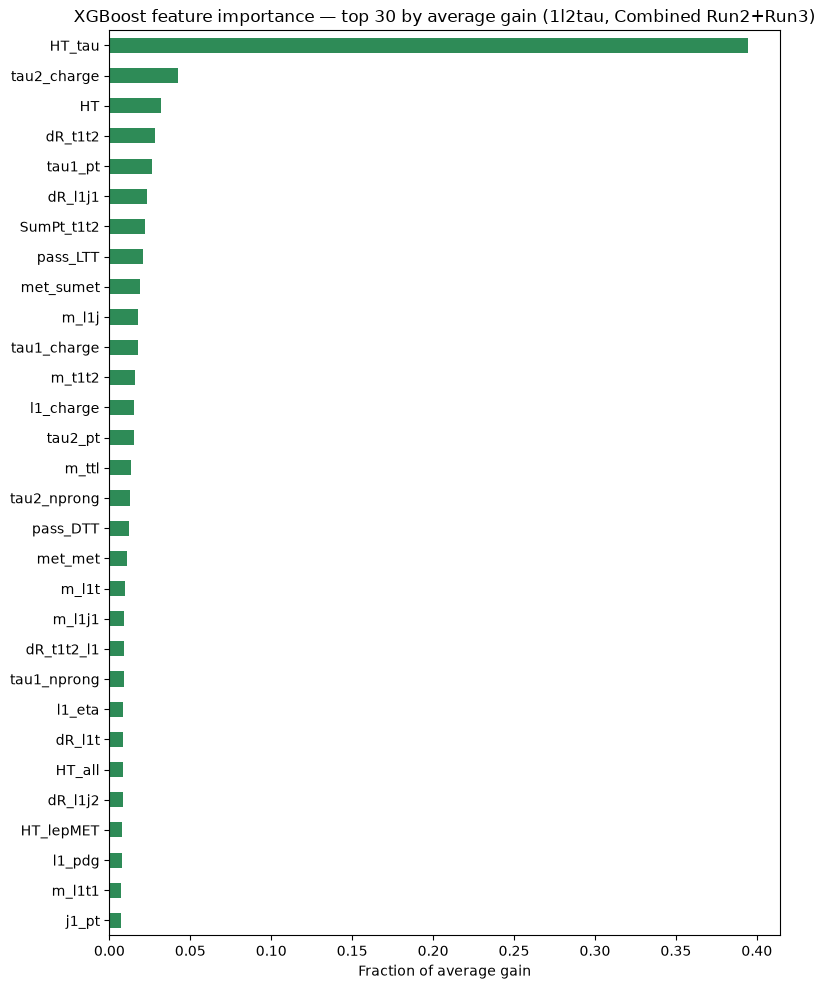

In [ ]:
# --- Feature importance by average gain (check against total_gain ranking) --
# gain = average loss reduction per split on that feature (unlike total_gain,
# it is NOT inflated by how many times a feature is used).

imp_by_gain = imp.sort_values("gain", ascending=False).copy()
imp_by_gain["gain_share"] = imp_by_gain["gain"] / imp_by_gain["gain"].sum()

print("Top 30 features by average gain (Combined Run2+Run3):")
print(imp_by_gain[["gain", "gain_share", "weight"]].head(30).to_string())

fig, ax = plt.subplots(figsize=(8, 10))
imp_by_gain["gain_share"].head(TOP_N)[::-1].plot.barh(ax=ax, color="seagreen")
ax.set_xlabel("Fraction of average gain")
ax.set_title(f"XGBoost feature importance — top {TOP_N} by average gain (1l2tau, Combined Run2+Run3)")
plt.tight_layout()
plt.show()


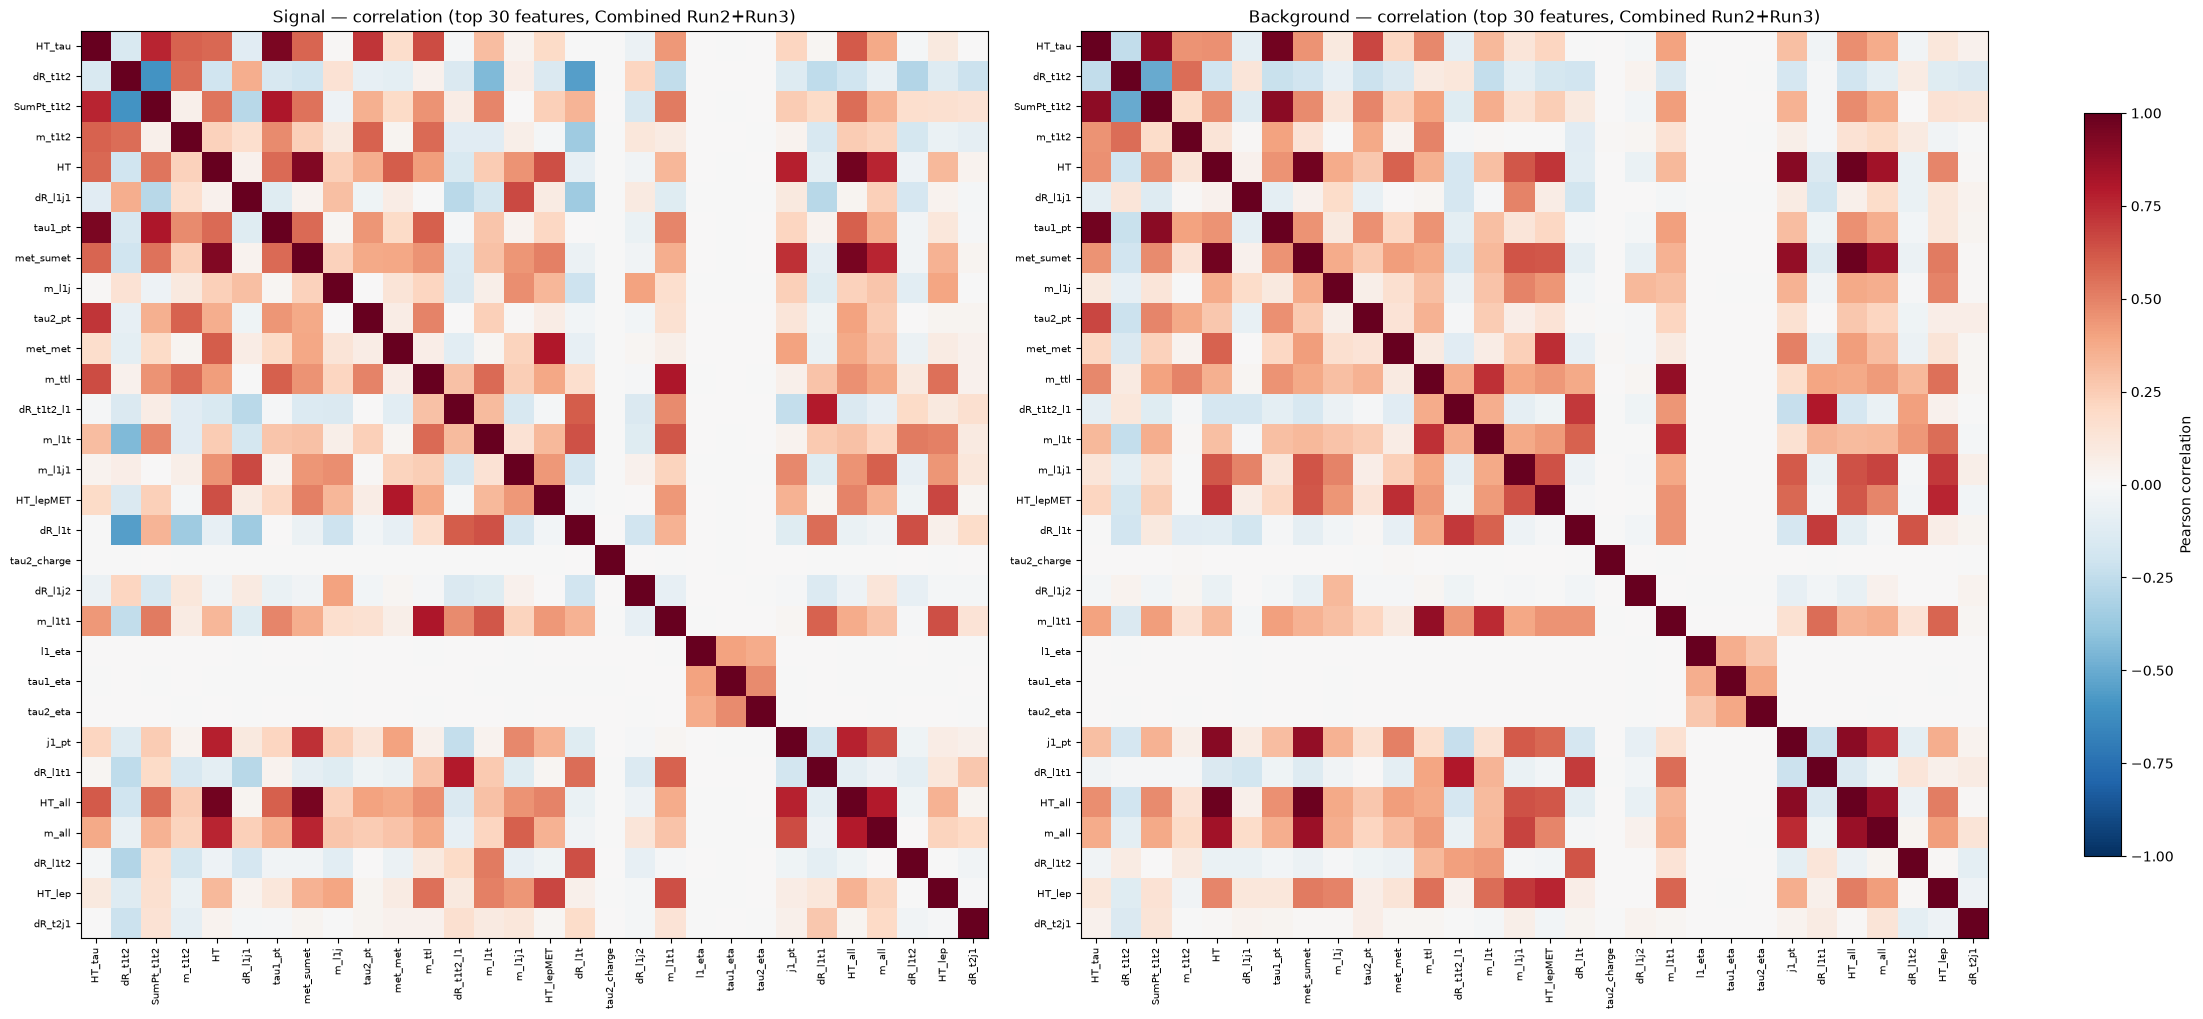

Pairs with |corr| > 0.50 (signal):
HT          HT_all        0.966265
met_sumet   HT_all        0.949262
HT_tau      tau1_pt       0.944697
HT          met_sumet     0.925993
SumPt_t1t2  tau1_pt       0.810478
m_ttl       m_l1t1        0.808434
met_met     HT_lepMET     0.797994
dR_t1t2_l1  dR_l1t1       0.794381
HT_all      m_all         0.792123
HT          j1_pt         0.778276
j1_pt       HT_all        0.773087
HT_tau      SumPt_t1t2    0.765479
HT          m_all         0.762113
met_sumet   m_all         0.758895
            j1_pt         0.733829
HT_tau      tau2_pt       0.712720
HT_lepMET   HT_lep        0.668279
dR_l1j1     m_l1j1        0.660990
j1_pt       m_all         0.652899
HT_tau      m_ttl         0.650382
HT          HT_lepMET     0.647770
dR_l1t      dR_l1t2       0.646123
m_l1t1      HT_lep        0.645500
m_l1t       dR_l1t        0.637692
            m_l1t1        0.617966
HT_tau      HT_all        0.612300
HT          met_met       0.603205
dR_t1t2_l1  dR_l1t  

In [8]:
# --- Correlation of the top features (Combined Run2+Run3) ------------------
# Pearson correlation among the TOP_N most important features, separately for
# signal and background (correlations differ between the two by physics).

top_feats = imp.index[:TOP_N].tolist()

corr_sig = data.loc[data.label == 1, top_feats].corr()
corr_bkg = data.loc[data.label == 0, top_feats].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
for ax, corr, title in [(axes[0], corr_sig, "Signal"), (axes[1], corr_bkg, "Background")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=90, fontsize=7)
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels(top_feats, fontsize=7)
    ax.set_title(f"{title} — correlation (top {TOP_N} features, Combined Run2+Run3)")

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")
plt.show()

# Highly correlated pairs -> redundant, candidates to prune after importance

def top_pairs(corr, thr=0.50):
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corr_sig).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corr_bkg).to_string())


In [9]:
# --- Prune redundant (highly correlated) features down to N_KEEP -----------
# Walk the top_feats list in importance order (most important first). For each
# feature, check its correlation against every feature ALREADY kept (i.e. every
# more-important feature seen so far). If it's correlated > CORR_THRESH with
# any of them (in signal OR background), it's redundant -> drop it (it's the
# "second most important" of that pair, since the more important one is
# already kept). Stop once N_KEEP features have been kept.

CORR_THRESH = 0.75
N_KEEP = 20

# Conservative combination: a pair counts as redundant if EITHER regime shows
# near-degeneracy.
corr_max = corr_sig.abs().combine(corr_bkg.abs(), np.maximum)

kept, dropped = [], []
for feat in top_feats:
    redundant_with = next(
        (k for k in kept if corr_max.loc[feat, k] > CORR_THRESH), None
    )
    if redundant_with is None:
        kept.append(feat)
    else:
        dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
    if len(kept) == N_KEEP:
        break

if len(kept) < N_KEEP:
    print(f"WARNING: only {len(kept)}/{N_KEEP} survivors found within top_feats "
          f"({len(top_feats)} features) - raise TOP_N or lower CORR_THRESH.")

print(f"Kept {len(kept)} decorrelated features (most -> least important):")
for i, feat in enumerate(kept, 1):
    print(f"  {i:2d}. {feat}")

print(f"\nDropped {len(dropped)} redundant features (|corr| > {CORR_THRESH} with a more important feature):")
for feat, because_of, corr_val in dropped:
    print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

PRUNED_FEATURES = kept


Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. dR_t1t2
   3. m_t1t2
   4. HT
   5. dR_l1j1
   6. m_l1j
   7. tau2_pt
   8. met_met
   9. m_ttl
  10. dR_t1t2_l1
  11. m_l1t
  12. m_l1j1
  13. dR_l1t
  14. tau2_charge
  15. dR_l1j2
  16. l1_eta
  17. tau1_eta
  18. tau2_eta
  19. dR_l1t2
  20. HT_lep

Dropped 9 redundant features (|corr| > 0.75 with a more important feature):
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.897)
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.967)
  met_sumet       -> redundant with HT              (|corr| = 0.962)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.798)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.879)
  j1_pt           -> redundant with HT              (|corr| = 0.911)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  HT_all          -> redundant with HT              (|corr| = 0.979)
  m_all           -> redundant with HT    

## Run after cut (Combined Run 2 + Run 3)


In [ ]:
# --- Retrain baseline XGBoost using only the pruned top-20 features (Combined) --
.90861
[50]	validation_0-auc:0.93248
[100]	validation_0-auc:0.93566
[150]	validation_0-auc:0.93699
[200]	validation_0-auc:0.93788
[250]	validation_0-auc:0.93828
[300]	validation_0-auc:0.93839
[350]	validation_0-auc:0.93852
[369]	validation_0-auc:0.93853

Best iteration: 339
model_pruned = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.10,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
)

model_pruned.fit(
    X_train[PRUNED_FEATURES], y_train,
    sample_weight=w_fit,
    eval_set=[(X_val[PRUNED_FEATURES], y_val)],
    sample_weight_eval_set=[w_val_fit],
    verbose=50,
)

print(f"\nBest iteration: {model_pruned.best_iteration}")
auc_train_pruned = roc_auc_score(y_train, model_pruned.predict_proba(X_train[PRUNED_FEATURES])[:, 1], sample_weight=np.abs(w_train))
auc_val_pruned   = roc_auc_score(y_val,   model_pruned.predict_proba(X_val[PRUNED_FEATURES])[:, 1],   sample_weight=w_val_fit)
print(f"Weighted AUC (pruned {len(PRUNED_FEATURES)} features): train = {auc_train_pruned:.4f} | validation = {auc_val_pruned:.4f}")
print(f"Comparison - full {len(features)}-feature baseline:    train = {auc_train:.4f} | validation = {auc_val:.4f}")


[0]	validation_0-auc:0.90861
[50]	validation_0-auc:0.93248
[100]	validation_0-auc:0.93566
[150]	validation_0-auc:0.93699
[200]	validation_0-auc:0.93788
[250]	validation_0-auc:0.93828
[300]	validation_0-auc:0.93839
[350]	validation_0-auc:0.93852
[369]	validation_0-auc:0.93853

Best iteration: 339
Weighted AUC (pruned 20 features): train = 0.9575 | validation = 0.9386
Comparison - full 68-feature baseline:    train = 0.9697 | validation = 0.9479


Pruned model (20 features) - importance by total gain (Combined Run2+Run3):
               total_gain  gain_frac  weight
HT_tau       2.659360e+06   0.437930  1301.0
HT           7.765574e+05   0.127880  1354.0
dR_t1t2      5.210307e+05   0.085801  1610.0
tau2_pt      3.268777e+05   0.053829  1198.0
dR_l1j1      2.244857e+05   0.036967  1126.0
m_t1t2       2.211050e+05   0.036410  1308.0
m_l1j        1.516442e+05   0.024972   953.0
met_met      1.397158e+05   0.023008  1308.0
dR_t1t2_l1   1.306913e+05   0.021522  1151.0
m_ttl        1.264393e+05   0.020821  1115.0
m_l1t        1.171808e+05   0.019297  1150.0
m_l1j1       1.062495e+05   0.017497  1057.0
dR_l1j2      9.889875e+04   0.016286  1127.0
tau2_eta     8.658250e+04   0.014258  1125.0
l1_eta       8.328872e+04   0.013716   958.0
tau1_eta     8.263151e+04   0.013607  1137.0
HT_lep       7.865935e+04   0.012953  1074.0
dR_l1t       7.719032e+04   0.012711   950.0
dR_l1t2      6.114917e+04   0.010070   905.0
tau2_charge  2.826028e+0

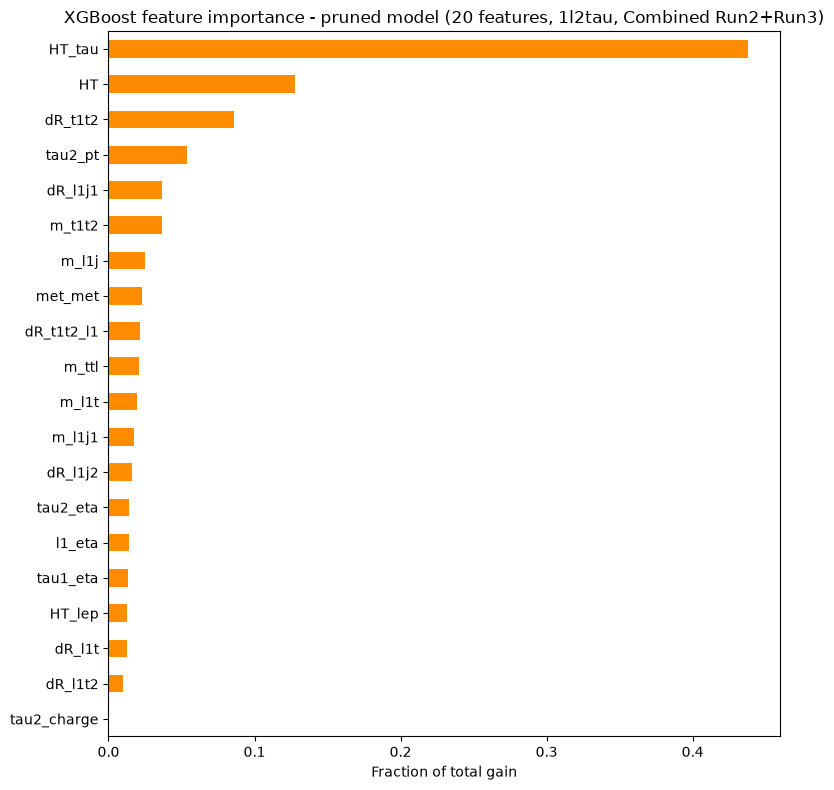

In [11]:
# --- Feature importance of the pruned model (Combined Run2+Run3) -----------
booster_pruned = model_pruned.get_booster()

imp_pruned = pd.DataFrame({
    t: booster_pruned.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(PRUNED_FEATURES).fillna(0.0)

imp_pruned = imp_pruned.sort_values("total_gain", ascending=False)
imp_pruned["gain_frac"] = imp_pruned["total_gain"] / imp_pruned["total_gain"].sum()

print("Pruned model (20 features) - importance by total gain (Combined Run2+Run3):")
print(imp_pruned[["total_gain", "gain_frac", "weight"]].to_string())
print(f"\nFeatures never used in a split: {(imp_pruned['total_gain'] == 0).sum()} / {len(PRUNED_FEATURES)}")

fig, ax = plt.subplots(figsize=(8, 8))
imp_pruned["gain_frac"][::-1].plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance - pruned model ({len(PRUNED_FEATURES)} features, 1l2tau, Combined Run2+Run3)")
plt.tight_layout()
plt.show()


## Did the ranking change? Combined vs Run-2-only

`First_Training.ipynb` persisted the Run-2-only Optuna-tuned, decorrelated
top-20 feature set to `optuna_features_run2.json`. Compare that Run-2-only
ranking against where those same features land in the Combined Run2+Run3
baseline ranking computed above (`imp`, full feature set, sorted by
total gain).


In [12]:
import json

# Run-2-only Optuna feature set (decorrelated top-20), persisted by First_Training.ipynb
with open(BASE_DIR_R2 / "optuna_features_run2.json") as f:
    run2_only_features = json.load(f)

# Rank position of each feature in the two models (1 = most important)
combined_rank = {feat: i + 1 for i, feat in enumerate(imp.index)}
combined_pruned_rank = {feat: i + 1 for i, feat in enumerate(imp_pruned.index)}

rows = []
for i, feat in enumerate(run2_only_features, start=1):
    rows.append({
        "feature": feat,
        "run2_only_rank": i,
        "combined_rank": combined_rank.get(feat, None),
        "combined_pruned_rank": combined_pruned_rank.get(feat, "not kept"),
    })

rank_compare = pd.DataFrame(rows).set_index("feature")
print(f"Run-2-only top-{len(run2_only_features)} features vs their rank in the Combined Run2+Run3 model:")
print(rank_compare.to_string())

# Simple rank-shift summary (only where the feature survives combined pruning)
comparable = rank_compare.dropna(subset=["combined_rank"])
rank_shift = (comparable["combined_rank"] - comparable["run2_only_rank"]).abs()
print(f"\nMean |rank shift| (baseline, full feature set): {rank_shift.mean():.1f} positions")
print(f"Max |rank shift|: {rank_shift.max():.0f} positions ({rank_shift.idxmax()})")

print(f"\nTop 10 features of the Combined Run2+Run3 model:")
print(list(imp.index[:10]))
print(f"\nTop 10 features of the Run-2-only model (optuna_features_run2.json):")
print(run2_only_features[:10])


Run-2-only top-20 features vs their rank in the Combined Run2+Run3 model:
            run2_only_rank  combined_rank combined_pruned_rank
feature                                                       
HT_tau                   1              1                    1
dR_t1t2                  2              2                    3
m_t1t2                   3              4                    6
met_sumet                4              8             not kept
dR_l1j1                  5              6                    5
m_l1j                    6              9                    7
tau2_pt                  7             10                    4
met_met                  8             11                    8
m_ttl                    9             12                   10
m_l1j1                  10             15                   12
m_l1t                   11             14                   11
dR_t1t2_l1              12             13                    9
tau1_eta                13             22   